# Modelos Benchmark — Comparacion con DAE-GRU
## Deteccion de Anomalias No Supervisada en ADRs Colombianos

**Proyecto:** Deteccion de Anomalias en Mercados Accionarios Colombianos mediante Deep Learning  
**Activos:** Ecopetrol (EC), Bancolombia (CIB), Grupo Aval (AVAL), Tecnoglass (TGLS)  
**Autores:** Mariana Franco — Danier Conde

---

### Estructura del Notebook

| Seccion | Contenido |
|---|---|
| 1 | Configuracion y carga de artefactos |
| 2 | Etiquetas de anomalia y protocolo de evaluacion |
| 3 | Modelos benchmark clasicos (Z-Score, Isolation Forest, One-Class SVM) |
| 4 | Modelos benchmark recurrentes (LSTM Predictor, GRU Predictor) |
| 5 | DAE-LSTM y DAE-GRU como referencia |
| 6 | Tabla comparativa, curvas PR y visualizacion |

---

### Protocolo de evaluacion

- **Entrenamiento:** exclusivamente sobre el conjunto de entrenamiento (2015-2019).
- **Umbral:** percentil 75 del score sobre el conjunto de validacion (2020).
  Justificacion: el periodo COVID-2020 es un evento de magnitud excepcional que
  infla artificialmente el umbral cuando se usa p95, dejando sin deteccion
  eventos de menor magnitud pero igualmente anomalos en el periodo de test.
  El p75 captura anomalias moderadas y severas sin requerir la magnitud COVID.
- **Evaluacion final:** conjunto de test (2021-2024).
- **Metrica principal:** AUC-PR. En datasets desbalanceados (25.7% anomalos
  en test) la curva Precision-Recall es mas informativa que la ROC porque
  penaliza explicitamente los falsos positivos. La literatura reciente
  (Zamanzadeh Darban et al., 2024) recomienda AUC-PR como metrica primaria
  para deteccion de anomalias en series de tiempo.
- **Metricas secundarias:** AUC-ROC, Precision, Recall, F1-Score.

### Exclusion de modelos supervisados

Random Forest y XGBoost fueron excluidos por incompatibilidad metodologica:
requieren etiquetas de anomalia durante el entrenamiento, violando el marco
no supervisado del proyecto.

---
## 1. Configuracion y Carga de Artefactos

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_PATH    = Path(r'C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder')
DATA_PATH    = BASE_PATH / 'data'   / 'processed'
SCALERS_PATH = BASE_PATH / 'models' / 'scalers'
AE_PATH      = BASE_PATH / 'models' / 'autoencoder'
BENCH_PATH   = BASE_PATH / 'models' / 'benchmarks'
OUTPUTS_PATH = BASE_PATH / 'outputs'

BENCH_PATH.mkdir(parents=True, exist_ok=True)
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

TICKERS      = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES        = {'EC': 'Ecopetrol', 'CIB': 'Bancolombia',
                'AVAL': 'Grupo Aval', 'TGLS': 'Tecnoglass'}
COLORS       = {'EC': '#1f77b4', 'CIB': '#ff7f0e',
                'AVAL': '#2ca02c', 'TGLS': '#d62728'}
FEATURE_COLS = ['log_return', 'vol_21d', 'vol_zscore']
SEQ_LEN      = 30
N_FEATURES   = len(FEATURE_COLS)

TRAIN_END  = '2019-12-31'
VAL_START  = '2020-01-01'
VAL_END    = '2020-12-31'
TEST_START = '2021-01-01'
TEST_END   = '2024-12-31'

ANOMALY_PERIODS = [
    {'name': 'Crisis petroleo', 'start': '2015-07-01', 'end': '2016-02-01'},
    {'name': 'COVID-19',        'start': '2020-02-15', 'end': '2020-05-01'},
    {'name': 'Fed hikes',       'start': '2022-01-01', 'end': '2022-12-31'},
]

REFERENCE_PERIODS = [
    {'name': 'Tornado Dallas',  'start': '2019-10-01', 'end': '2019-11-30'},
]

# Umbral: percentil 75 sobre validacion
# Justificacion: COVID-2020 es un evento excepcional que infla p95 artificialmente.
# p75 detecta anomalias moderadas y severas sin requerir la magnitud del COVID.
THRESHOLD_PERCENTILE = 75

print('Configuracion cargada.')
print(f'  TensorFlow           : {tf.__version__}')
print(f'  Umbral percentil     : p{THRESHOLD_PERCENTILE}')

Configuracion cargada.
  TensorFlow           : 2.21.0
  Umbral percentil     : p75


In [2]:
# Carga de artefactos desde NB2
windows = {}
scalers = {}
dfs     = {}

for ticker in TICKERS:
    windows[ticker] = {}
    for split in ['train', 'val', 'test']:
        windows[ticker][split] = np.load(
            DATA_PATH / f'{ticker}_{split}_windows.npy'
        )
    with open(SCALERS_PATH / f'{ticker}_scaler.pkl', 'rb') as f:
        scalers[ticker] = pickle.load(f)
    dfs[ticker] = pd.read_csv(
        DATA_PATH / f'{ticker}.csv',
        parse_dates=True, index_col=0
    )

print('Artefactos cargados.')
for ticker in TICKERS:
    print(f'  [{ticker}]  train={windows[ticker]["train"].shape}  '
          f'val={windows[ticker]["val"].shape}  '
          f'test={windows[ticker]["test"].shape}')

Artefactos cargados.
  [EC]  train=(1208, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)
  [CIB]  train=(1208, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)
  [AVAL]  train=(1208, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)
  [TGLS]  train=(1149, 30, 3)  val=(224, 30, 3)  test=(975, 30, 3)


---
## 2. Etiquetas de Anomalia y Protocolo de Evaluacion

**Construccion de etiquetas**

Una ventana se etiqueta como anomala (y=1) si su ultimo timestep cae dentro
de algun periodo de crisis conocido. Las ventanas fuera de estos periodos
se tratan como normales (y=0).

**Nota sobre el desbalance en test**

El conjunto de test (2021-2024) tiene aproximadamente 25% de ventanas anomalas.
Esto se debe principalmente a que el ciclo de alzas de la Fed (2022) cubre
un ano completo. Este desbalance es moderado pero debe tenerse en cuenta
al interpretar las metricas: AUC-PR es la metrica mas adecuada en este contexto.

In [3]:
def build_labels(index, anomaly_periods):
    labels = pd.Series(0, index=index)
    for ap in anomaly_periods:
        mask = (index >= ap['start']) & (index <= ap['end'])
        labels[mask] = 1
    return labels.values


def get_window_index(df, split_start, split_end, seq_len):
    df_split = df.loc[split_start:split_end].dropna(subset=FEATURE_COLS)
    return df_split.index[seq_len - 1:]


def evaluate_model(scores_val, scores_test, labels_val, labels_test,
                   model_name, ticker, threshold_pct=THRESHOLD_PERCENTILE):
    """
    Evalua un modelo dado sus scores de anomalia.

    Umbral: percentil threshold_pct del score sobre validacion.
    Metricas reportadas sobre test:
      - AUC-PR  (metrica principal)
      - AUC-ROC
      - Precision, Recall, F1 con umbral p{threshold_pct}

    Los scores completos se retornan para construccion de curvas PR/ROC reales.
    """
    tau = np.percentile(scores_val, threshold_pct)
    preds = (scores_test >= tau).astype(int)

    auc_roc = roc_auc_score(labels_test, scores_test) \
              if labels_test.sum() > 0 else np.nan
    auc_pr  = average_precision_score(labels_test, scores_test) \
              if labels_test.sum() > 0 else np.nan

    return {
        'modelo':     model_name,
        'ticker':     ticker,
        'auc_pr':     auc_pr,
        'auc_roc':    auc_roc,
        'precision':  precision_score(labels_test, preds, zero_division=0),
        'recall':     recall_score(labels_test, preds, zero_division=0),
        'f1':         f1_score(labels_test, preds, zero_division=0),
        'tau':        tau,
        'scores_val':  scores_val,
        'scores_test': scores_test,
        'preds_test':  preds,
    }


# Construir indices y etiquetas
idx_val  = {}
idx_test = {}
y_val    = {}
y_test   = {}

for ticker in TICKERS:
    idx_val[ticker]  = get_window_index(dfs[ticker], VAL_START,   VAL_END,   SEQ_LEN)
    idx_test[ticker] = get_window_index(dfs[ticker], TEST_START,  TEST_END,  SEQ_LEN)
    y_val[ticker]    = build_labels(idx_val[ticker],  ANOMALY_PERIODS)
    y_test[ticker]   = build_labels(idx_test[ticker], ANOMALY_PERIODS)

print('Etiquetas construidas.')
print(f"{'Activo':<14}  {'Anomalas val':>14}  {'% val':>6}  "
      f"{'Anomalas test':>14}  {'% test':>6}")
print('-' * 62)
for ticker in TICKERS:
    nv = y_val[ticker].sum();  tv = len(y_val[ticker])
    nt = y_test[ticker].sum(); tt = len(y_test[ticker])
    print(f"{NAMES[ticker]:<14}  {nv:>14}  {nv/tv*100:>5.1f}%  "
          f"{nt:>14}  {nt/tt*100:>5.1f}%")

Etiquetas construidas.
Activo            Anomalas val   % val   Anomalas test  % test
--------------------------------------------------------------
Ecopetrol                   53   23.7%             251   25.7%
Bancolombia                 53   23.7%             251   25.7%
Grupo Aval                  53   23.7%             251   25.7%
Tecnoglass                  53   23.7%             251   25.7%


---
## 3. Modelos Benchmark Clasicos

Z-Score, Isolation Forest y One-Class SVM operan sobre vectores i.i.d.
Para cada ventana de T=30 timesteps se promedia en el eje temporal,
obteniendo un vector de dimension F=3 que representa la ventana.

In [4]:
def window_to_vector(X):
    """Colapsa (n, T, F) -> (n, F) promediando en el eje temporal."""
    return X.mean(axis=1)


results_all = []

# ─── Z-Score ────────────────────────────────────────────────────────────────
print('Z-Score')
print('-' * 50)
for ticker in TICKERS:
    X_tr = window_to_vector(windows[ticker]['train'])
    X_vl = window_to_vector(windows[ticker]['val'])
    X_te = window_to_vector(windows[ticker]['test'])

    mu    = X_tr.mean(axis=0)
    sigma = X_tr.std(axis=0) + 1e-8

    scores_val  = np.sqrt(((X_vl - mu) / sigma) ** 2).sum(axis=1)
    scores_test = np.sqrt(((X_te - mu) / sigma) ** 2).sum(axis=1)

    res = evaluate_model(scores_val, scores_test,
                         y_val[ticker], y_test[ticker], 'Z-Score', ticker)
    results_all.append(res)
    print(f"  [{ticker}]  AUC-PR={res['auc_pr']:.4f}  AUC-ROC={res['auc_roc']:.4f}  "
          f"F1={res['f1']:.4f}  Prec={res['precision']:.4f}  Rec={res['recall']:.4f}")

# ─── Isolation Forest ───────────────────────────────────────────────────────
print('\nIsolation Forest')
print('-' * 50)
for ticker in TICKERS:
    X_tr = window_to_vector(windows[ticker]['train'])
    X_vl = window_to_vector(windows[ticker]['val'])
    X_te = window_to_vector(windows[ticker]['test'])

    iforest = IsolationForest(n_estimators=200, contamination=0.05,
                               random_state=SEED, n_jobs=-1)
    iforest.fit(X_tr)

    scores_val  = -iforest.decision_function(X_vl)
    scores_test = -iforest.decision_function(X_te)

    res = evaluate_model(scores_val, scores_test,
                         y_val[ticker], y_test[ticker],
                         'Isolation Forest', ticker)
    results_all.append(res)
    with open(BENCH_PATH / f'iforest_{ticker}.pkl', 'wb') as f:
        pickle.dump(iforest, f)
    print(f"  [{ticker}]  AUC-PR={res['auc_pr']:.4f}  AUC-ROC={res['auc_roc']:.4f}  "
          f"F1={res['f1']:.4f}  Prec={res['precision']:.4f}  Rec={res['recall']:.4f}")

# ─── One-Class SVM ──────────────────────────────────────────────────────────
print('\nOne-Class SVM')
print('-' * 50)
for ticker in TICKERS:
    X_tr = window_to_vector(windows[ticker]['train'])
    X_vl = window_to_vector(windows[ticker]['val'])
    X_te = window_to_vector(windows[ticker]['test'])

    ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
    ocsvm.fit(X_tr)

    scores_val  = -ocsvm.decision_function(X_vl)
    scores_test = -ocsvm.decision_function(X_te)

    res = evaluate_model(scores_val, scores_test,
                         y_val[ticker], y_test[ticker],
                         'One-Class SVM', ticker)
    results_all.append(res)
    with open(BENCH_PATH / f'ocsvm_{ticker}.pkl', 'wb') as f:
        pickle.dump(ocsvm, f)
    print(f"  [{ticker}]  AUC-PR={res['auc_pr']:.4f}  AUC-ROC={res['auc_roc']:.4f}  "
          f"F1={res['f1']:.4f}  Prec={res['precision']:.4f}  Rec={res['recall']:.4f}")

Z-Score
--------------------------------------------------
  [EC]  AUC-PR=0.5459  AUC-ROC=0.7485  F1=0.0391  Prec=1.0000  Rec=0.0199
  [CIB]  AUC-PR=0.5203  AUC-ROC=0.6984  F1=0.0314  Prec=1.0000  Rec=0.0159
  [AVAL]  AUC-PR=0.4470  AUC-ROC=0.6225  F1=0.0079  Prec=1.0000  Rec=0.0040
  [TGLS]  AUC-PR=0.4161  AUC-ROC=0.7027  F1=0.2058  Prec=0.5333  Rec=0.1275

Isolation Forest
--------------------------------------------------
  [EC]  AUC-PR=0.5614  AUC-ROC=0.7730  F1=0.0692  Prec=1.0000  Rec=0.0359
  [CIB]  AUC-PR=0.6080  AUC-ROC=0.7795  F1=0.1544  Prec=1.0000  Rec=0.0837
  [AVAL]  AUC-PR=0.4770  AUC-ROC=0.6504  F1=0.1392  Prec=0.8636  Rec=0.0757
  [TGLS]  AUC-PR=0.4215  AUC-ROC=0.7070  F1=0.1859  Prec=0.4754  Rec=0.1155

One-Class SVM
--------------------------------------------------
  [EC]  AUC-PR=0.4250  AUC-ROC=0.6967  F1=0.0000  Prec=0.0000  Rec=0.0000
  [CIB]  AUC-PR=0.5809  AUC-ROC=0.7377  F1=0.0000  Prec=0.0000  Rec=0.0000
  [AVAL]  AUC-PR=0.4397  AUC-ROC=0.6595  F1=0.0000  Pre

---
## 4. Modelos Benchmark Recurrentes: LSTM Predictor y GRU Predictor

El score de anomalia es el MSE entre el timestep predicho y el observado.
Este paradigma asume predictibilidad de la serie, supuesto debil en retornos
financieros aproximadamente ruido blanco.

In [5]:
def build_predictor(seq_len, n_features, units=64, dropout=0.2,
                    cell_type='LSTM', name='Predictor'):
    RNN    = layers.LSTM if cell_type == 'LSTM' else layers.GRU
    inputs = keras.Input(shape=(seq_len - 1, n_features))
    x      = RNN(units, return_sequences=False)(inputs)
    x      = layers.Dropout(dropout)(x)
    x      = layers.Dense(32, activation='relu')(x)
    out    = layers.Dense(n_features)(x)
    model  = Model(inputs, out, name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return model


def prepare_predictor_data(X):
    return X[:, :-1, :].astype(np.float32), X[:, -1, :].astype(np.float32)


def predictor_score(model, X):
    Xin, ytrue = prepare_predictor_data(X)
    ypred      = model.predict(Xin, verbose=0)
    return np.mean((ytrue - ypred) ** 2, axis=1)


for cell_type in ['LSTM', 'GRU']:
    print(f'{cell_type} Predictor')
    print('-' * 50)
    for ticker in TICKERS:
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED); np.random.seed(SEED)

        X_tr_w = windows[ticker]['train'].astype(np.float32)
        X_vl_w = windows[ticker]['val'].astype(np.float32)
        X_te_w = windows[ticker]['test'].astype(np.float32)
        Xtr, ytr = prepare_predictor_data(X_tr_w)
        Xvl, yvl = prepare_predictor_data(X_vl_w)

        model = build_predictor(SEQ_LEN, N_FEATURES, cell_type=cell_type,
                                 name=f'{cell_type}_Pred_{ticker}')
        es    = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                        restore_best_weights=True, verbose=0)
        model.fit(Xtr, ytr, validation_data=(Xvl, yvl),
                  epochs=100, batch_size=32, callbacks=[es], verbose=0)

        scores_val  = predictor_score(model, X_vl_w)
        scores_test = predictor_score(model, X_te_w)

        res = evaluate_model(scores_val, scores_test,
                              y_val[ticker], y_test[ticker],
                              f'{cell_type} Predictor', ticker)
        results_all.append(res)
        model.save(BENCH_PATH / f'{cell_type}_Predictor_{ticker}.keras')
        print(f"  [{ticker}]  AUC-PR={res['auc_pr']:.4f}  AUC-ROC={res['auc_roc']:.4f}  "
              f"F1={res['f1']:.4f}  Prec={res['precision']:.4f}  Rec={res['recall']:.4f}"
              f"  (epochs={len(model.history.history['loss'])}")
    print()

LSTM Predictor
--------------------------------------------------

  [EC]  AUC-PR=0.3556  AUC-ROC=0.6063  F1=0.2093  Prec=0.3871  Rec=0.1434  (epochs=27
  [CIB]  AUC-PR=0.3354  AUC-ROC=0.5808  F1=0.1075  Prec=0.5357  Rec=0.0598  (epochs=29
  [AVAL]  AUC-PR=0.3315  AUC-ROC=0.5707  F1=0.2266  Prec=0.3922  Rec=0.1594  (epochs=29
  [TGLS]  AUC-PR=0.3058  AUC-ROC=0.5692  F1=0.2264  Prec=0.3500  Rec=0.1673  (epochs=22

GRU Predictor
--------------------------------------------------
  [EC]  AUC-PR=0.3519  AUC-ROC=0.6015  F1=0.2071  Prec=0.4023  Rec=0.1394  (epochs=36
  [CIB]  AUC-PR=0.3258  AUC-ROC=0.5740  F1=0.1111  Prec=0.4324  Rec=0.0637  (epochs=28
  [AVAL]  AUC-PR=0.3131  AUC-ROC=0.5407  F1=0.2376  Prec=0.3874  Rec=0.1713  (epochs=37
  [TGLS]  AUC-PR=0.3047  AUC-ROC=0.5655  F1=0.2274  Prec=0.3235  Rec=0.1753  (epochs=22



---
## 5. DAE-LSTM y DAE-GRU como Referencia

Modelos entrenados en NB3. Score: MSE de reconstruccion sin ruido en inferencia.
Evaluados bajo el mismo protocolo que los benchmarks.

In [6]:
for cell_type in ['LSTM', 'GRU']:
    print(f'DAE-{cell_type}')
    print('-' * 50)
    for ticker in TICKERS:
        tf.keras.backend.clear_session()
        model = keras.models.load_model(AE_PATH / f'DAE_{cell_type}_{ticker}.keras')

        X_vl = windows[ticker]['val'].astype(np.float32)
        X_te = windows[ticker]['test'].astype(np.float32)

        pred_vl = model.predict(X_vl, verbose=0)
        pred_te = model.predict(X_te, verbose=0)

        scores_val  = np.mean((X_vl - pred_vl) ** 2, axis=(1, 2))
        scores_test = np.mean((X_te - pred_te) ** 2, axis=(1, 2))

        res = evaluate_model(scores_val, scores_test,
                              y_val[ticker], y_test[ticker],
                              f'DAE-{cell_type}', ticker)
        results_all.append(res)
        print(f"  [{ticker}]  AUC-PR={res['auc_pr']:.4f}  AUC-ROC={res['auc_roc']:.4f}  "
              f"F1={res['f1']:.4f}  Prec={res['precision']:.4f}  Rec={res['recall']:.4f}")
    print()

DAE-LSTM
--------------------------------------------------
  [EC]  AUC-PR=0.7187  AUC-ROC=0.7985  F1=0.0000  Prec=0.0000  Rec=0.0000
  [CIB]  AUC-PR=0.6053  AUC-ROC=0.7564  F1=0.0000  Prec=0.0000  Rec=0.0000
  [AVAL]  AUC-PR=0.6159  AUC-ROC=0.7413  F1=0.1269  Prec=1.0000  Rec=0.0677
  [TGLS]  AUC-PR=0.4936  AUC-ROC=0.7507  F1=0.1672  Prec=0.4333  Rec=0.1036

DAE-GRU
--------------------------------------------------
  [EC]  AUC-PR=0.7137  AUC-ROC=0.7931  F1=0.0000  Prec=0.0000  Rec=0.0000
  [CIB]  AUC-PR=0.6023  AUC-ROC=0.7632  F1=0.0000  Prec=0.0000  Rec=0.0000
  [AVAL]  AUC-PR=0.6125  AUC-ROC=0.7245  F1=0.1544  Prec=1.0000  Rec=0.0837
  [TGLS]  AUC-PR=0.4905  AUC-ROC=0.7479  F1=0.1587  Prec=0.3906  Rec=0.0996



---
## 6. Tabla Comparativa, Curvas PR y Visualizacion

**Metrica principal: AUC-PR.** Justificacion: dataset desbalanceado (25% anomalos
en test), la curva Precision-Recall penaliza correctamente los falsos positivos
y es independiente del umbral seleccionado.

In [7]:
MODEL_ORDER = ['Z-Score', 'Isolation Forest', 'One-Class SVM',
               'LSTM Predictor', 'GRU Predictor', 'DAE-LSTM', 'DAE-GRU']

MODEL_COLORS = {
    'Z-Score':          '#aec7e8',
    'Isolation Forest': '#ffbb78',
    'One-Class SVM':    '#98df8a',
    'LSTM Predictor':   '#c5b0d5',
    'GRU Predictor':    '#f7b6d2',
    'DAE-LSTM':         '#9467bd',
    'DAE-GRU':          '#d62728',
}

# DataFrame de resultados (sin columnas de scores — solo metricas)
metrics_cols = ['modelo', 'ticker', 'auc_pr', 'auc_roc',
                'precision', 'recall', 'f1', 'tau']
results_df   = pd.DataFrame([{k: r[k] for k in metrics_cols}
                               for r in results_all])

# Tabla por activo
print('TABLA COMPARATIVA — TEST 2021-2024')
print(f'Umbral: p{THRESHOLD_PERCENTILE} del score en validacion')
print('Metrica principal: AUC-PR')
print('=' * 85)

for ticker in TICKERS:
    sub = results_df[results_df['ticker'] == ticker].copy()
    sub['modelo'] = pd.Categorical(sub['modelo'],
                                    categories=MODEL_ORDER, ordered=True)
    sub = sub.sort_values('auc_pr', ascending=False)

    print(f'\n{NAMES[ticker]} ({ticker})')
    print(f"  {'Modelo':<18}  {'AUC-PR':>8}  {'AUC-ROC':>8}  "
          f"{'F1':>8}  {'Precision':>10}  {'Recall':>8}")
    print('  ' + '-' * 68)
    for _, row in sub.iterrows():
        marker = ' <--' if row['modelo'] == 'DAE-GRU' else ''
        print(f"  {row['modelo']:<18}  "
              f"{row['auc_pr']:>8.4f}  {row['auc_roc']:>8.4f}  "
              f"{row['f1']:>8.4f}  {row['precision']:>10.4f}  "
              f"{row['recall']:>8.4f}{marker}")

TABLA COMPARATIVA — TEST 2021-2024
Umbral: p75 del score en validacion
Metrica principal: AUC-PR

Ecopetrol (EC)
  Modelo                AUC-PR   AUC-ROC        F1   Precision    Recall
  --------------------------------------------------------------------
  DAE-LSTM              0.7187    0.7985    0.0000      0.0000    0.0000
  DAE-GRU               0.7137    0.7931    0.0000      0.0000    0.0000 <--
  Isolation Forest      0.5614    0.7730    0.0692      1.0000    0.0359
  Z-Score               0.5459    0.7485    0.0391      1.0000    0.0199
  One-Class SVM         0.4250    0.6967    0.0000      0.0000    0.0000
  LSTM Predictor        0.3556    0.6063    0.2093      0.3871    0.1434
  GRU Predictor         0.3519    0.6015    0.2071      0.4023    0.1394

Bancolombia (CIB)
  Modelo                AUC-PR   AUC-ROC        F1   Precision    Recall
  --------------------------------------------------------------------
  Isolation Forest      0.6080    0.7795    0.1544      1.0000   

In [8]:
# Resumen global — promedio entre activos
summary = (results_df
           .groupby('modelo')[['auc_pr', 'auc_roc', 'f1', 'precision', 'recall']]
           .mean()
           .round(4))
summary.index = pd.CategoricalIndex(summary.index,
                                     categories=MODEL_ORDER, ordered=True)
summary = summary.sort_values('auc_pr', ascending=False)

print('RESUMEN GLOBAL — PROMEDIO ENTRE 4 ACTIVOS (ordenado por AUC-PR)')
print('=' * 70)
print(summary.to_string())

# Ranking
print('\nRANKING POR AUC-PR:')
for i, (model, row) in enumerate(summary.iterrows(), 1):
    marker = ' <-- modelo final del proyecto' if model == 'DAE-GRU' else ''
    print(f'  {i}. {model:<18}  AUC-PR={row["auc_pr"]:.4f}  '
          f'AUC-ROC={row["auc_roc"]:.4f}  F1={row["f1"]:.4f}{marker}')

results_df.to_csv(BENCH_PATH / 'benchmark_results.csv', index=False)
summary.to_csv(BENCH_PATH / 'benchmark_summary.csv')
print(f'\nResultados guardados en {BENCH_PATH}')

RESUMEN GLOBAL — PROMEDIO ENTRE 4 ACTIVOS (ordenado por AUC-PR)
                  auc_pr  auc_roc      f1  precision  recall
modelo                                                      
DAE-LSTM          0.6084   0.7617  0.0735     0.3583  0.0428
DAE-GRU           0.6048   0.7572  0.0783     0.3477  0.0458
Isolation Forest  0.5170   0.7275  0.1372     0.8348  0.0777
Z-Score           0.4823   0.6930  0.0710     0.8833  0.0418
One-Class SVM     0.4589   0.6783  0.0505     0.1086  0.0329
LSTM Predictor    0.3321   0.5817  0.1925     0.4162  0.1325
GRU Predictor     0.3238   0.5704  0.1958     0.3864  0.1375

RANKING POR AUC-PR:
  1. DAE-LSTM            AUC-PR=0.6084  AUC-ROC=0.7617  F1=0.0735
  2. DAE-GRU             AUC-PR=0.6048  AUC-ROC=0.7572  F1=0.0783 <-- modelo final del proyecto
  3. Isolation Forest    AUC-PR=0.5170  AUC-ROC=0.7275  F1=0.1372
  4. Z-Score             AUC-PR=0.4823  AUC-ROC=0.6930  F1=0.0710
  5. One-Class SVM       AUC-PR=0.4589  AUC-ROC=0.6783  F1=0.0505
  6. L

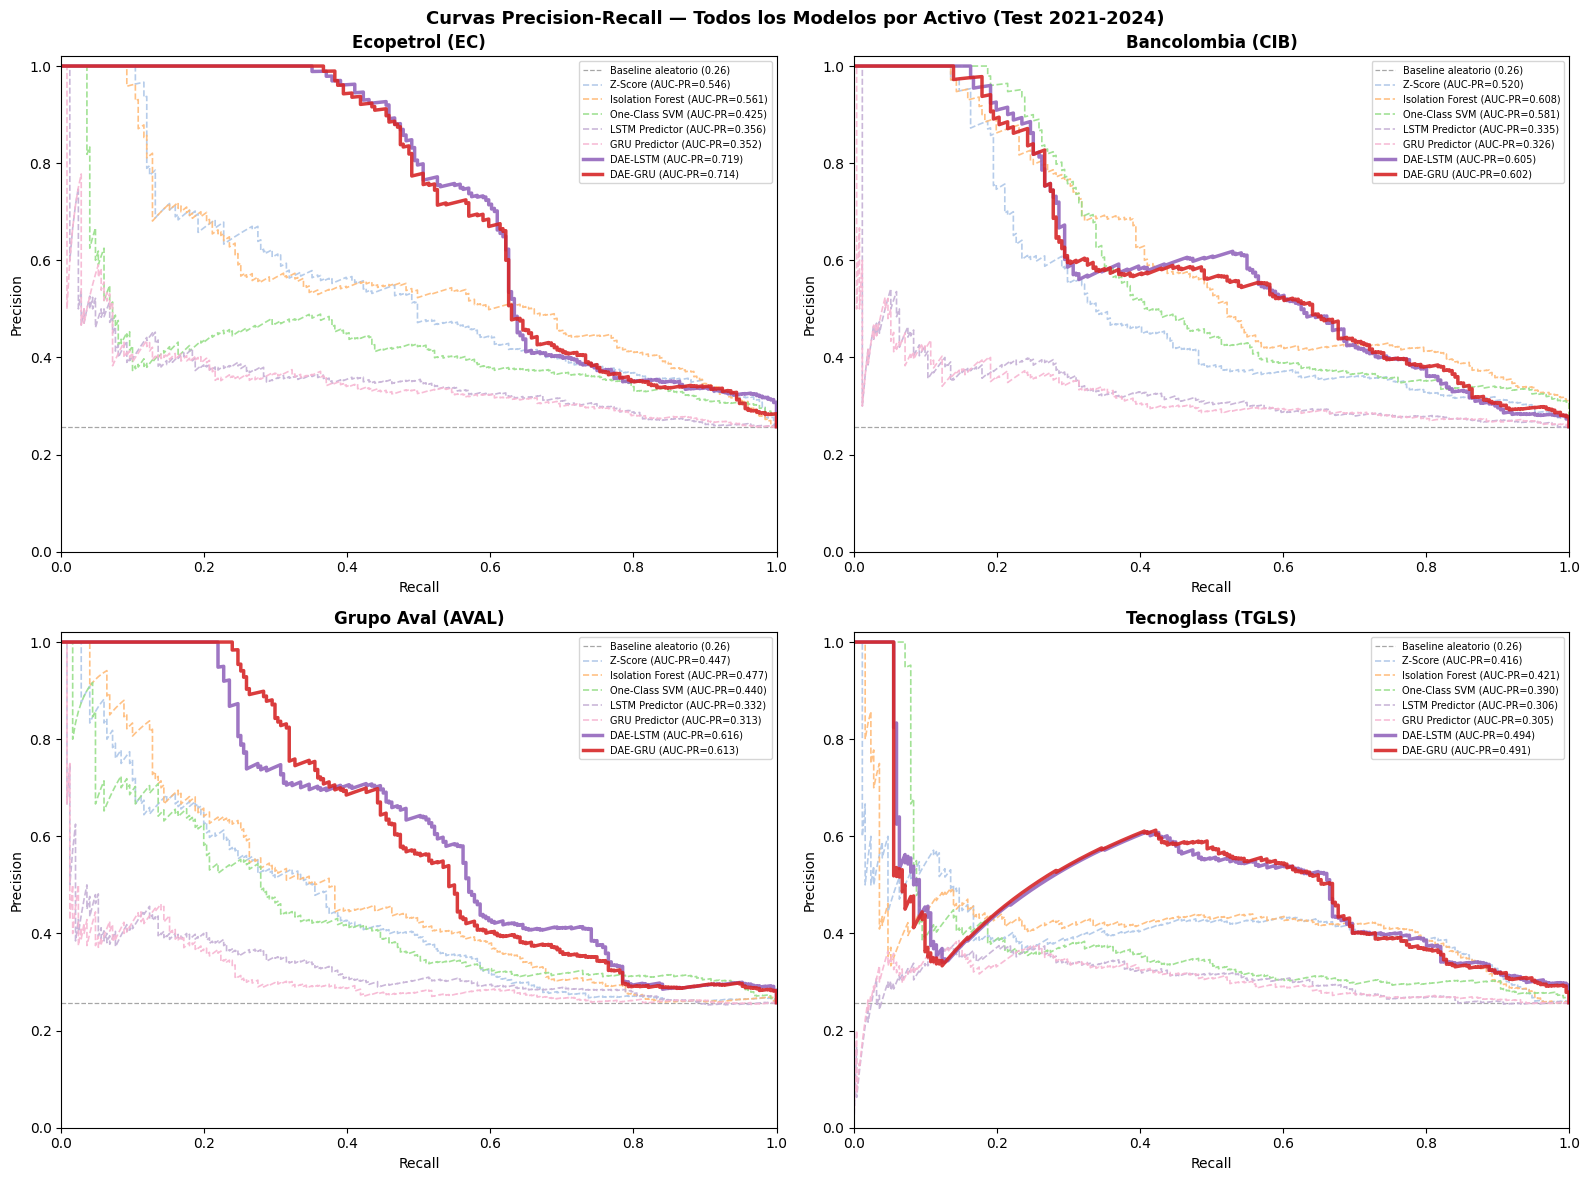

In [9]:
# Curvas Precision-Recall reales por activo — todos los modelos
# AUC-PR es la metrica principal: esta figura es el argumento visual central

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]

    # Baseline: precision del clasificador aleatorio = fraccion de positivos
    baseline = y_test[ticker].mean()
    ax.axhline(baseline, color='grey', linestyle='--',
               linewidth=0.9, alpha=0.7,
               label=f'Baseline aleatorio ({baseline:.2f})')

    for res in results_all:
        if res['ticker'] != ticker:
            continue
        prec, rec, _ = precision_recall_curve(
            y_test[ticker], res['scores_test']
        )
        color = MODEL_COLORS.get(res['modelo'], 'grey')
        lw    = 2.5 if 'DAE' in res['modelo'] else 1.2
        ls    = '-' if 'DAE' in res['modelo'] else '--'
        label = f"{res['modelo']} (AUC-PR={res['auc_pr']:.3f})"
        ax.plot(rec, prec, color=color, linewidth=lw,
                linestyle=ls, label=label, alpha=0.9)

    ax.set_title(f'{NAMES[ticker]} ({ticker})', fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle(
    'Curvas Precision-Recall — Todos los Modelos por Activo (Test 2021-2024)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_benchmark_pr_curves.png',
            dpi=120, bbox_inches='tight')
plt.show()

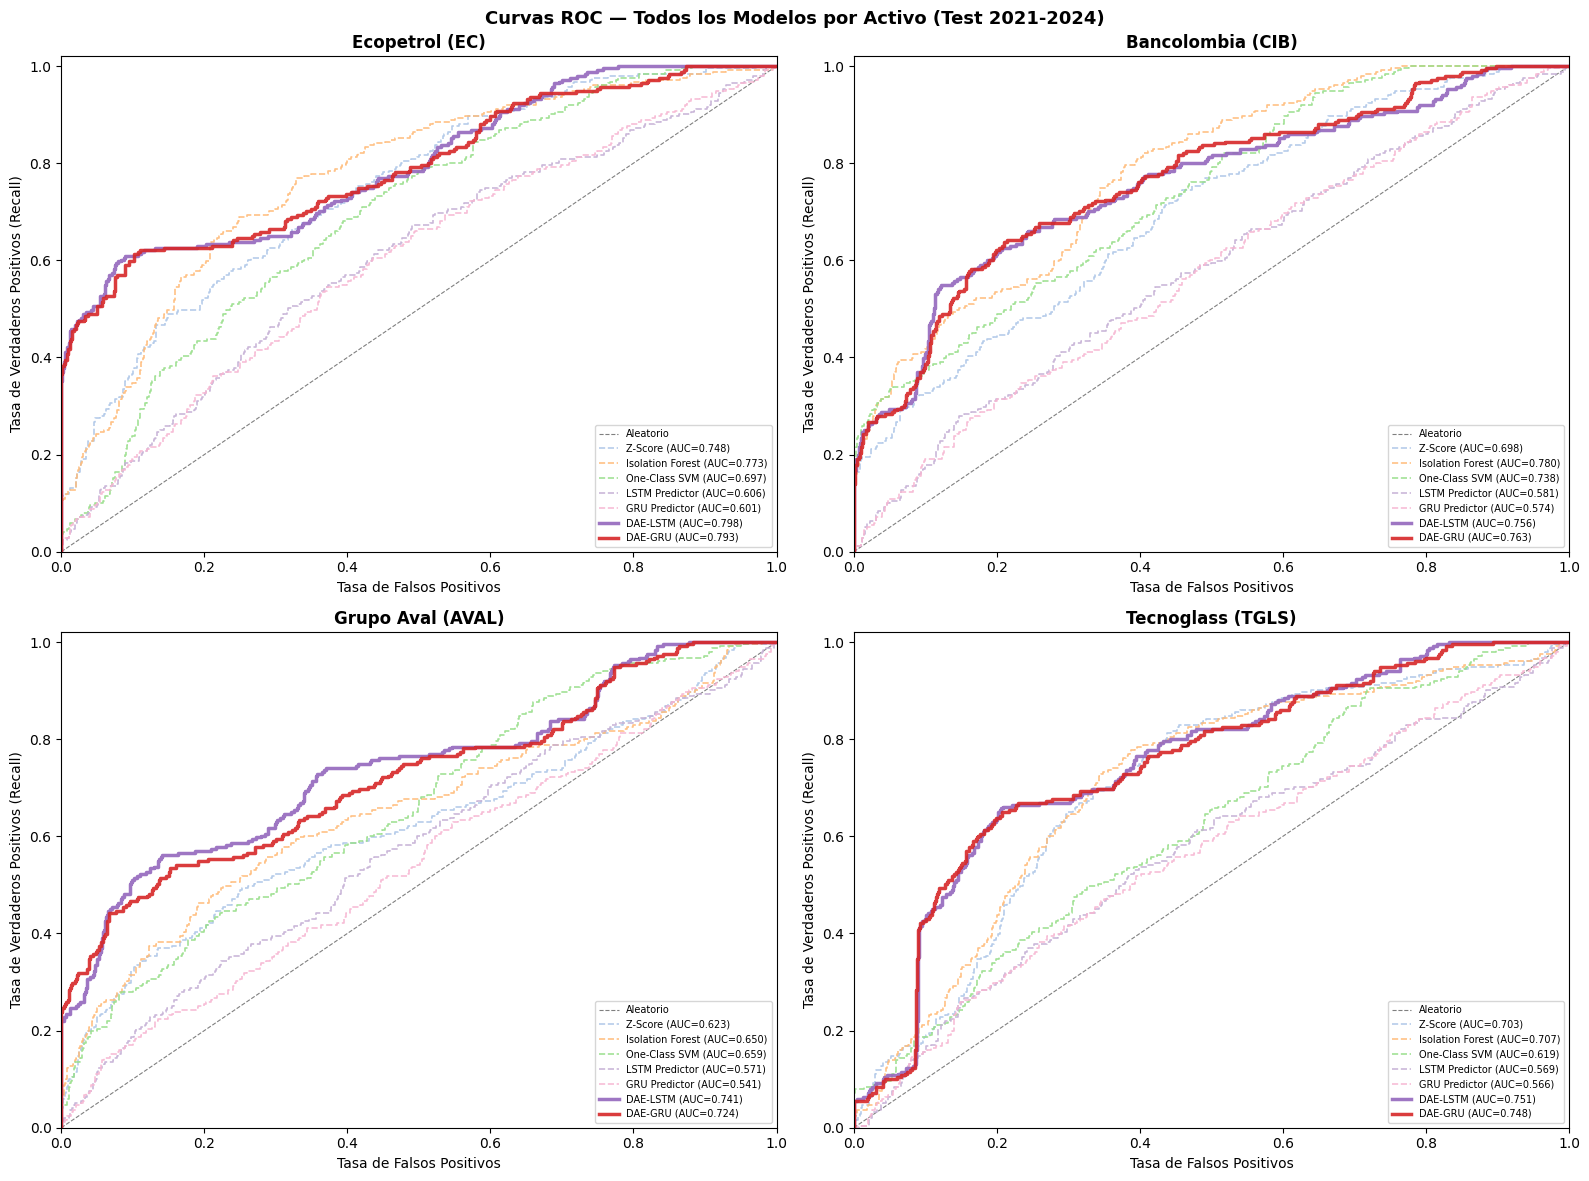

In [10]:
# Curvas ROC reales por activo — todos los modelos

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5, label='Aleatorio')

    for res in results_all:
        if res['ticker'] != ticker:
            continue
        fpr, tpr, _ = roc_curve(y_test[ticker], res['scores_test'])
        color = MODEL_COLORS.get(res['modelo'], 'grey')
        lw    = 2.5 if 'DAE' in res['modelo'] else 1.2
        ls    = '-' if 'DAE' in res['modelo'] else '--'
        label = f"{res['modelo']} (AUC={res['auc_roc']:.3f})"
        ax.plot(fpr, tpr, color=color, linewidth=lw,
                linestyle=ls, label=label, alpha=0.9)

    ax.set_title(f'{NAMES[ticker]} ({ticker})', fontweight='bold')
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle(
    'Curvas ROC — Todos los Modelos por Activo (Test 2021-2024)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_benchmark_roc_curves.png',
            dpi=120, bbox_inches='tight')
plt.show()

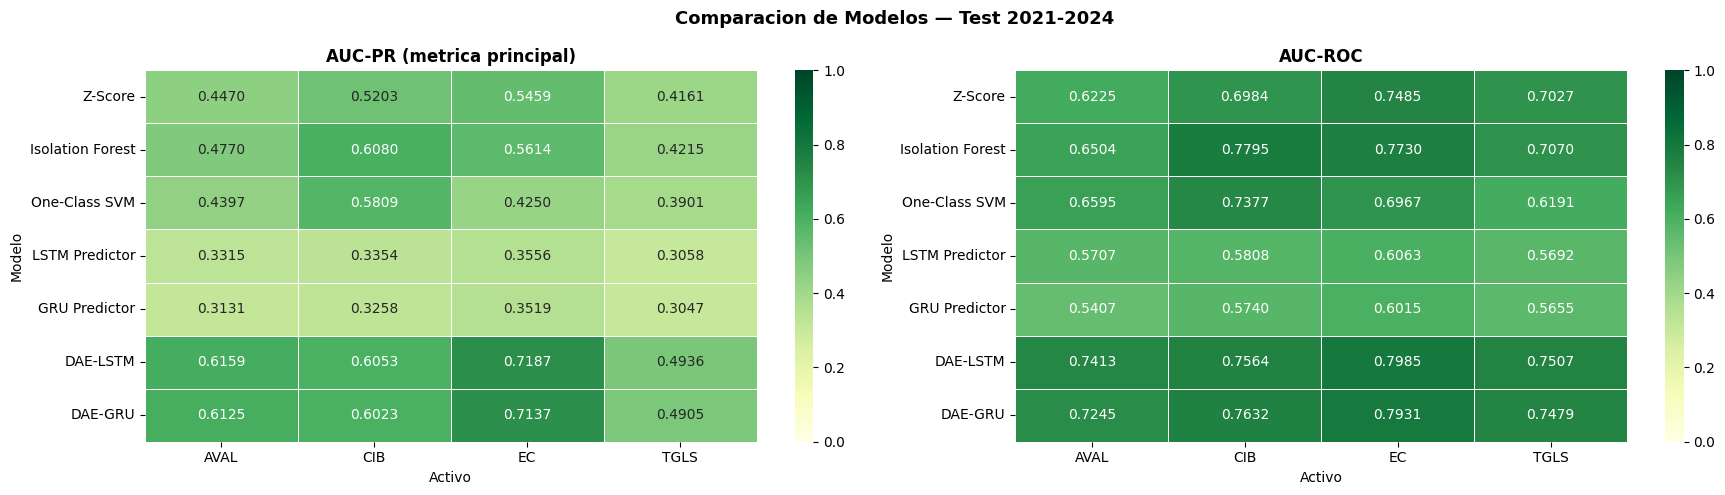

In [11]:
# Heatmap AUC-PR y AUC-ROC por modelo y activo
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    ['auc_pr',  'auc_roc'],
    ['AUC-PR (metrica principal)', 'AUC-ROC']
):
    pivot = results_df.pivot(index='modelo', columns='ticker', values=metric)
    pivot = pivot.reindex([m for m in MODEL_ORDER if m in pivot.index])

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.4f',
        cmap='YlGn', vmin=0, vmax=1,
        linewidths=0.5
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Activo')
    ax.set_ylabel('Modelo')

plt.suptitle('Comparacion de Modelos — Test 2021-2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_benchmark_heatmap.png',
            dpi=120, bbox_inches='tight')
plt.show()

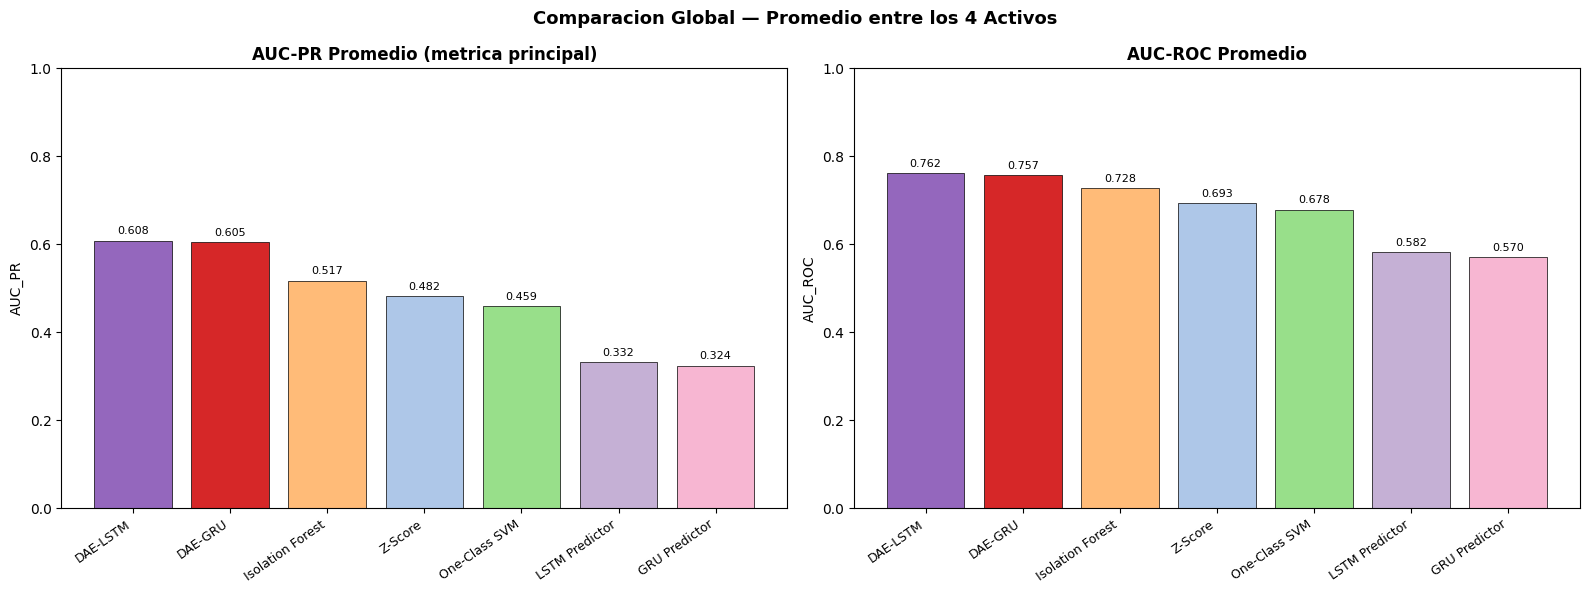

In [12]:
# Grafico de barras: AUC-PR y AUC-ROC promedio por modelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(
    axes,
    ['auc_pr', 'auc_roc'],
    ['AUC-PR Promedio (metrica principal)', 'AUC-ROC Promedio']
):
    vals   = summary[metric]
    colors_bar = [MODEL_COLORS.get(m, 'grey') for m in vals.index]
    bars   = ax.bar(range(len(vals)), vals.values,
                    color=colors_bar, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(metric.upper())
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparacion Global — Promedio entre los 4 Activos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_benchmark_barras.png',
            dpi=120, bbox_inches='tight')
plt.show()

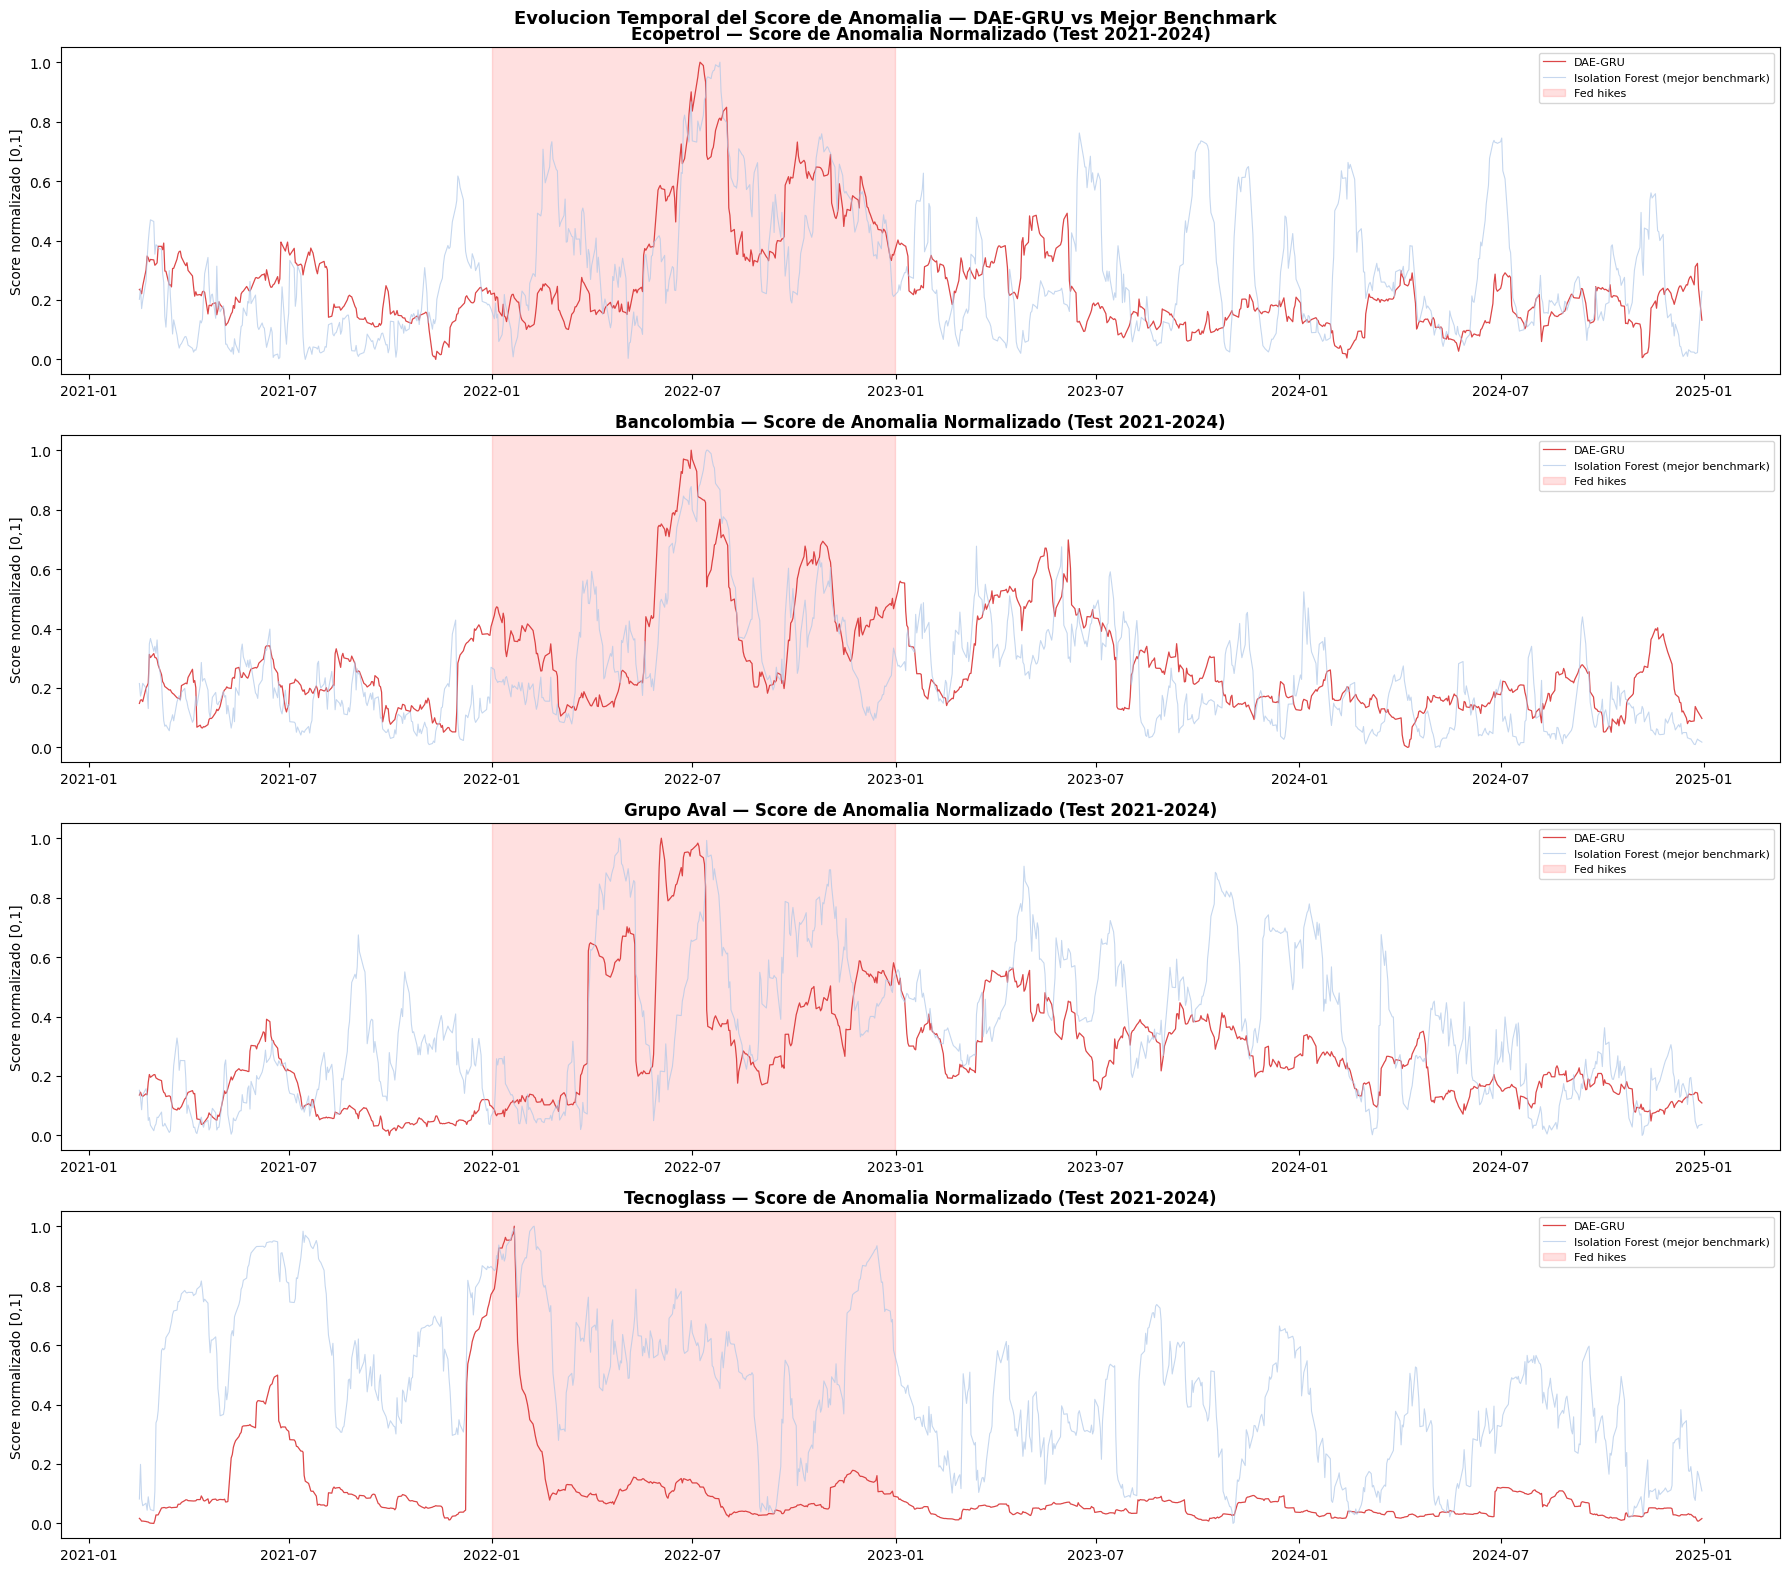

In [13]:
# Score de anomalia en el tiempo — DAE-GRU vs mejor benchmark por activo
# Visualizacion cualitativa: verificar que los picos coinciden con crisis conocidas

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(18, 4 * len(TICKERS)),
                          sharex=False)

for i, ticker in enumerate(TICKERS):
    ax = axes[i]

    # Identificar mejor benchmark por AUC-PR para este activo
    sub_bench = results_df[
        (results_df['ticker'] == ticker) &
        (~results_df['modelo'].isin(['DAE-LSTM', 'DAE-GRU']))
    ].sort_values('auc_pr', ascending=False)
    best_bench_name = sub_bench.iloc[0]['modelo']

    # Scores de DAE-GRU y mejor benchmark en test
    dae_scores   = next(r['scores_test'] for r in results_all
                        if r['ticker'] == ticker and r['modelo'] == 'DAE-GRU')
    bench_scores = next(r['scores_test'] for r in results_all
                        if r['ticker'] == ticker and r['modelo'] == best_bench_name)

    # Normalizar scores a [0,1] para comparacion visual
    def norm(s):
        return (s - s.min()) / (s.max() - s.min() + 1e-8)

    idx  = idx_test[ticker]
    tau_dae = next(r['tau'] for r in results_all
                   if r['ticker'] == ticker and r['modelo'] == 'DAE-GRU')

    ax.plot(idx, norm(dae_scores),
            color='#d62728', linewidth=0.9, alpha=0.85,
            label=f'DAE-GRU')
    ax.plot(idx, norm(bench_scores),
            color='#aec7e8', linewidth=0.8, alpha=0.7,
            label=f'{best_bench_name} (mejor benchmark)')

    # Periodos de anomalia en test
    for ap in ANOMALY_PERIODS:
        s = pd.Timestamp(ap['start'])
        e = pd.Timestamp(ap['end'])
        if e < idx.min() or s > idx.max():
            continue
        ax.axvspan(max(s, idx.min()), min(e, idx.max()),
                   alpha=0.12, color='red', label=ap['name'])
    
    for rp in REFERENCE_PERIODS:
        s = pd.Timestamp(rp['start'])
        e = pd.Timestamp(rp['end'])
        if e < idx.min() or s > idx.max():
            continue
        ax.axvspan(max(s, idx.min()), min(e, idx.max()),
                   alpha=0.12, color='green', label=rp['name'])

    ax.set_title(f'{NAMES[ticker]} — Score de Anomalia Normalizado (Test 2021-2024)',
                 fontweight='bold')
    ax.set_ylabel('Score normalizado [0,1]')

    # Leyenda sin duplicados
    handles, labels_leg = ax.get_legend_handles_labels()
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, labels_leg) if l not in seen
            and not seen.add(l)]
    ax.legend(*zip(*uniq), fontsize=8, loc='upper right')

plt.suptitle(
    'Evolucion Temporal del Score de Anomalia — DAE-GRU vs Mejor Benchmark',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_benchmark_scores_temporales.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# Exportar scores de todos los modelos para uso directo en NB6
scores_export = {}
for r in results_all:
    t = r['ticker']
    m = r['modelo']
    if t not in scores_export:
        scores_export[t] = {}
    scores_export[t][m] = {
        'val':  r['scores_val'],
        'test': r['scores_test'],
        'tau':  r['tau'],
    }

with open(OUTPUTS_PATH / 'all_scores.pkl', 'wb') as f:
    pickle.dump(scores_export, f)

print(f'Scores exportados: {OUTPUTS_PATH / "all_scores.pkl"}')

Scores exportados: C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\outputs\all_scores.pkl
